# Gold as a Diversifier: Has Its Role Changed Since the Global Financial Crisis?

## Introduction and Research Question

Gold has long been viewed as a “safe haven” asset, particularly during periods of financial uncertainty. Investors often turn to gold during market stress because it is generally seen as less tied to the performance of equities than most traditional assets.

The Global Financial Crisis (2007–2009) is a useful point to focus on because it was a period when many asset relationships changed quickly.

This project explores that question using daily price data for:


- GLD (SPDR Gold Shares ETF) as a proxy for gold
- SPY (SPDR S&P 500 ETF) as a proxy for US equities

Using Python, pandas, matplotlib, and financial market data from Yahoo Finance, the analysis examines:

- long-run performance trends
- rolling correlation patterns
- gold’s behaviour during negative equity market days
- portfolio diversification effects
- differences between pre-GFC, GFC, and post-GFC market environments

Rather than focusing on a single statistic, the project approaches diversification from several different angles. The aim is not simply to determine whether gold and equities were correlated on average, but to understand how that relationship behaved during different market conditions, especially during periods of financial stress.

## Data and Approach

To explore how gold behaved relative to equities over time, this project uses two widely traded exchange-traded funds (ETFs):

- GLD (SPDR Gold Shares ETF) as a proxy for gold  
- SPY (SPDR S&P 500 ETF) as a proxy for the US equity market  

Daily adjusted closing price data was downloaded using the `yfinance` Python package, covering the period from 2004 onwards. This time frame captures several very different market environments, including the Global Financial Crisis, the post-crisis recovery period, the COVID-19 shock, and more recent periods of market volatility.

The analysis focuses primarily on daily returns rather than raw prices, as returns provide a clearer way to compare how the two assets moved relative to one another through time.

The aim is not just to check whether gold and equities were correlated on average, but to see whether gold became more useful as a diversifier during periods of financial stress.

In [37]:
# import packages
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [38]:
# use ETFs because they are investable proxies
# GLD = gold, SPY = US equities
# start from 2004 because GLD data begins around then
gold = yf.download("GLD", start="2004-01-01", auto_adjust=True)
spy = yf.download("SPY", start="2004-01-01", auto_adjust=True)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [39]:
# quick check to see what the downloaded gold data looks like
gold.head()

Price,Close,High,Low,Open,Volume
Ticker,GLD,GLD,GLD,GLD,GLD
Date,,,,,
2004-11-18,44.380001,44.490002,44.070000,44.430000,5992000
2004-11-19,44.779999,44.919998,44.470001,44.490002,11655300
2004-11-22,44.950001,44.970001,44.740002,44.750000,11996000
2004-11-23,44.750000,44.919998,44.720001,44.880001,3169200
2004-11-24,45.049999,45.049999,44.790001,44.930000,6105100


In [40]:
# quick check to see what the downloaded SPY data looks like
spy.head()

Price,Close,High,Low,Open,Volume
Ticker,SPY,SPY,SPY,SPY,SPY
Date,,,,,
2004-01-02,73.833908,74.471151,73.502011,74.172440,38072300
2004-01-05,74.637100,74.690200,74.072871,74.139254,27959800
2004-01-06,74.710106,74.829589,74.345017,74.451226,20472800
2004-01-07,74.962395,75.048686,74.272047,74.603945,30170400
2004-01-08,75.261055,75.280973,74.856140,75.174763,36438400


In [41]:
# keep only closing prices and align both assets by trading date
data = pd.DataFrame()

data["Gold"] = gold["Close"]
data["SPY"] = spy["Close"]

data = data.dropna()

data.head()

,Gold,SPY
Date,,
2004-11-18,44.380001,79.950691
2004-11-19,44.779999,79.061913
2004-11-22,44.950001,79.438995
2004-11-23,44.750000,79.560188
2004-11-24,45.049999,79.748680


In [42]:
# use returns because diversification is about how assets move
# convert returns into growth of $100 for a clearer comparison


growth = (1 + returns).cumprod() * 100

returns.head()

,Gold,SPY
Date,,
2004-11-19,0.009013,-0.011116
2004-11-22,0.003796,0.004769
2004-11-23,-0.004449,0.001526
2004-11-24,0.006704,0.002369
2004-11-26,0.005327,-0.000760


## Output 1 - Starting Point: How Did $100 Grow in Gold vs Equities?

A useful starting point is to compare how both assets performed over the full sample period. While diversification is mainly concerned with how assets behave relative to one another, looking at long-run performance first helps provide broader context before examining correlation and market stress periods in more detail.

The chart below tracks the growth of a hypothetical $100 investment in both GLD and SPY from 2004 onwards.



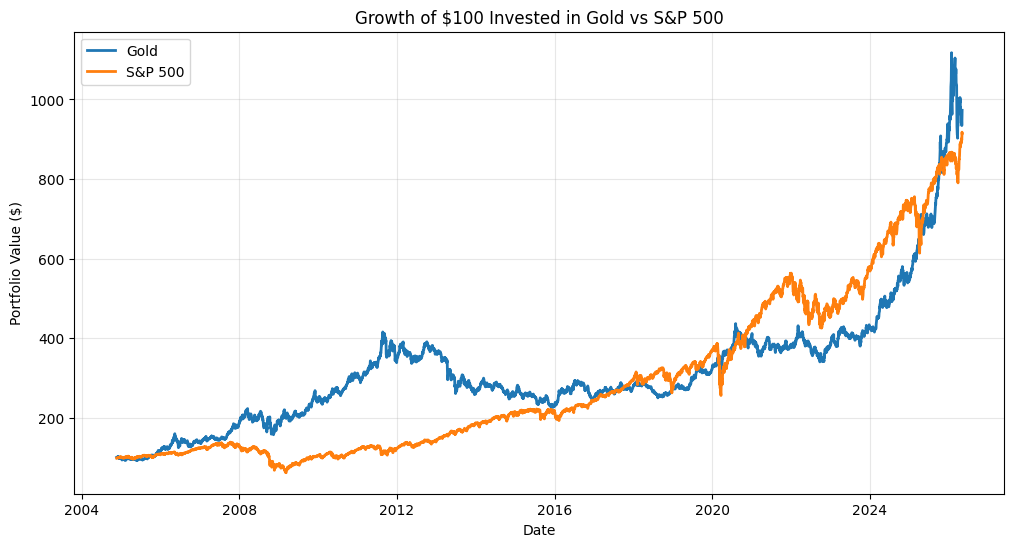

In [43]:
# compare the long-run path of gold and equities
# this is not enough to prove diversification, but it gives useful context before the correlation analysis
plt.figure(figsize=(12,6))

plt.plot(growth.index, growth["Gold"], label="Gold", linewidth=2)
plt.plot(growth.index, growth["SPY"], label="S&P 500", linewidth=2)

plt.title("Growth of $100 Invested in Gold vs S&P 500")
plt.xlabel("Date")
plt.ylabel("Portfolio Value ($)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

Although equities delivered much stronger long-run growth overall, the chart also shows that gold and equities did not always move in the same way.

The contrast is clearest around the Global Financial Crisis. Equities fell sharply, while gold was much more resilient. This gives an early indication of why gold is often discussed as a diversifier, especially during periods when equity markets are under pressure.

The trade-off is also clear. Gold helped soften some weaker periods, but equities still produced stronger cumulative returns over the full sample.

## Output 2- The Relationship Between Gold and Equities Was Not Stable

At first glance, gold and equities appear fairly independent. But looking at long-run performance alone does not fully explain diversification. Two assets can follow different price paths while still becoming more closely linked during certain market environments.

The next step examines how the relationship between gold and equities changed over time using rolling correlation.



In [44]:
# check full-sample correlation between gold and SPY returns
returns.corr()

,Gold,SPY
Gold,1.000000,0.059915
SPY,0.059915,1.000000


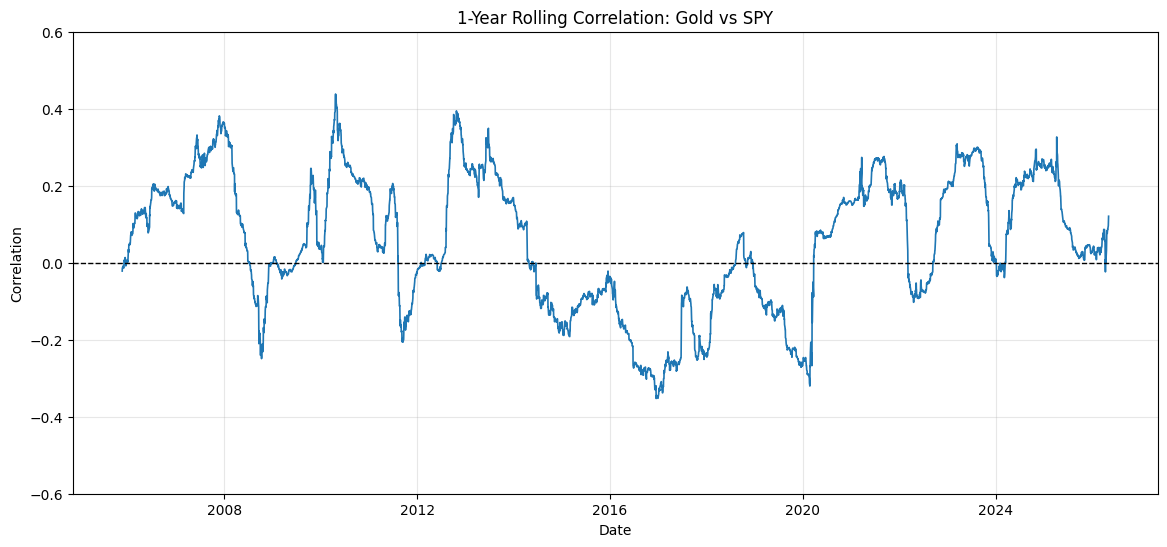

In [45]:
# a single full-sample correlation can hide how the relationship changes over time
# so I use a rolling 252-day window, which is roughly one trading year
rolling_corr = returns["Gold"].rolling(252).corr(returns["SPY"])

plt.figure(figsize=(14,6))

plt.plot(rolling_corr.index, rolling_corr.values, linewidth=1.2)

# the zero line helps me see when gold moves from positive to negative correlation with SPY
plt.axhline(y=0, color="black", linestyle="--", linewidth=1)

plt.title("1-Year Rolling Correlation: Gold vs SPY")
plt.xlabel("Date")
plt.ylabel("Correlation")
plt.ylim(-0.6, 0.6)
plt.grid(True, alpha=0.3)

plt.show()



The relationship between gold and equities changed quite a bit across the sample period rather than staying stable throughout.

One of the clearest shifts appears during the Global Financial Crisis. As equity markets became more volatile, gold behaved more independently from equities, making its diversification role more visible.

However, this pattern did not hold across the full sample. In several post-crisis periods, gold and equities began moving more closely together again, which shows that gold did not act as a reliable hedge in every market environment.

So the relationship is not as simple as saying gold always moves in the opposite direction to equities.

## Output 3- Did Gold Behave Differently When Equities Fell?

Rolling correlation provides a broader picture of how the relationship between gold and equities changed over time, but it does not fully capture how gold behaved during actual market declines.

The next section isolates trading days where SPY generated negative returns and compares how gold performed during those periods.

In [46]:
# isolate days when SPY had a negative return
down_days = returns[returns["SPY"] < 0]

down_days.head()

,Gold,SPY
Date,,
2004-11-19,0.009013,-0.011116
2004-11-26,0.005327,-0.000760
2004-11-29,0.002429,-0.004563
2004-12-03,0.014460,-0.000671
2004-12-06,-0.009430,-0.000335


In [47]:
# average returns on SPY down days, shown as percentages
down_avg = down_days.mean() * 100

down_avg

,0
Gold,-0.031819
SPY,-0.803748


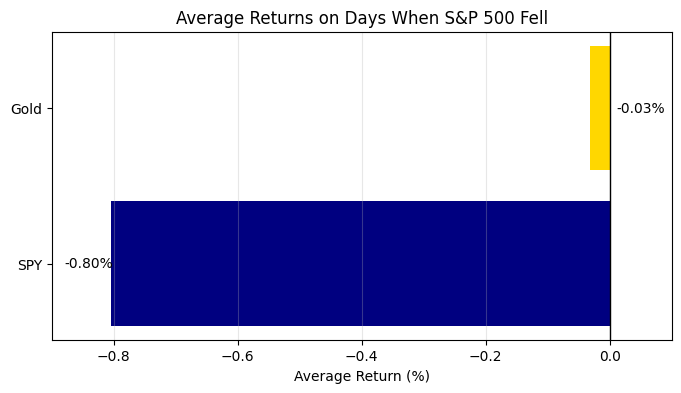

In [48]:
# compare average returns on SPY down days
# label the bars directly to make the chart easier to read
plt.figure(figsize=(8,4))

plt.barh(
    ["Gold", "SPY"],
    [down_avg["Gold"], down_avg["SPY"]],
    color=["gold", "navy"]
)

plt.gca().invert_yaxis()

plt.axvline(0, color="black", linewidth=1)

plt.title("Average Returns on Days When S&P 500 Fell")
plt.xlabel("Average Return (%)")

plt.xlim(-0.9, 0.1)

plt.text(0.01, 0, f'{down_avg["Gold"]:.2f}%', va='center')
plt.text(-0.88, 1, f'{down_avg["SPY"]:.2f}%', va='center')

plt.grid(axis="x", alpha=0.3)

plt.show()

Gold did not rise every time equities fell, but the average decline was much smaller than the fall in SPY.

That difference matters because diversification is not really about removing losses completely. Instead, it is more about reducing pressure on a portfolio during weaker market periods.

Even though gold was not a perfect offset, it generally behaved more defensively than equities during negative SPY trading days.


This is important because diversification does not necessarily mean an asset will always rise when equities fall. Instead, diversification is more about reducing overall portfolio vulnerability during periods of market stress.

## Output 4- Would a Mixed Portfolio Have Felt Different?

So far, the analysis has mainly focused on how gold and equities behaved relative to one another. However, diversification ultimately matters at the portfolio level rather than the individual asset level.

To examine this more practically, the next section compares the performance of a fully equity portfolio against a portfolio split between SPY (80%) and GLD (20%).

In [49]:
# compare pure equity with a simple 80/20 SPY-Gold portfolio
# 20% gold is a moderate diversification allocation
portfolio = pd.DataFrame()

portfolio["SPY Only"] = returns["SPY"]

portfolio["80_20 Mix"] = 0.8 * returns["SPY"] + 0.2 * returns["Gold"]

portfolio.head()

,SPY Only,80_20 Mix
Date,,
2004-11-19,-0.011116,-0.007090
2004-11-22,0.004769,0.004574
2004-11-23,0.001526,0.000331
2004-11-24,0.002369,0.003236
2004-11-26,-0.000760,0.000458


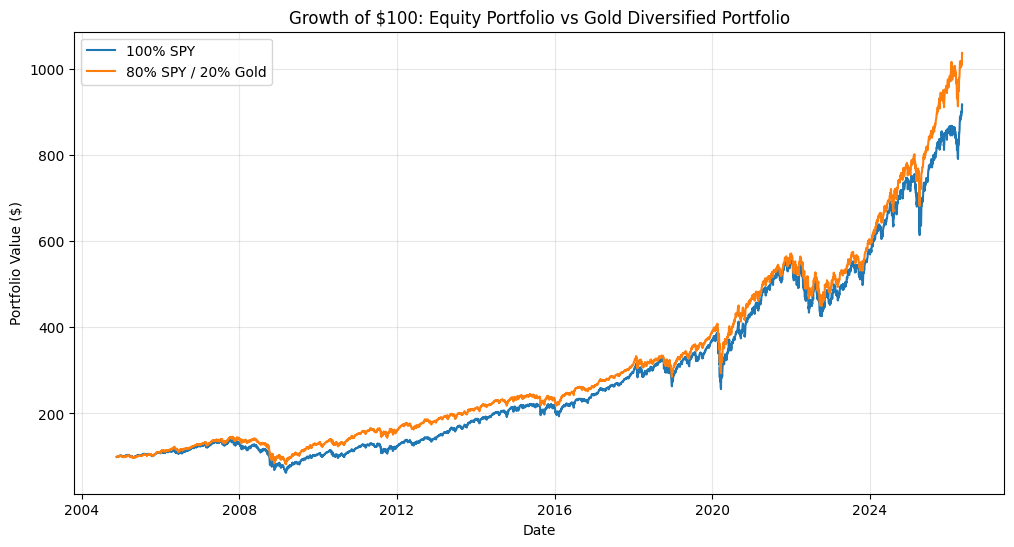

In [50]:
# convert portfolio returns into growth of $100
# this lets me compare what an investor would actually experience over time
portfolio_growth = (1 + portfolio).cumprod() * 100

plt.figure(figsize=(12,6))

plt.plot(portfolio_growth.index, portfolio_growth["SPY Only"], label="100% SPY")
plt.plot(portfolio_growth.index, portfolio_growth["80_20 Mix"], label="80% SPY / 20% Gold")

plt.title("Growth of $100: Equity Portfolio vs Gold Diversified Portfolio")
plt.xlabel("Date")
plt.ylabel("Portfolio Value ($)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

The diversified portfolio generally experienced smoother performance than the pure equity portfolio, particularly during periods of market stress.

Although the equity-only portfolio produced stronger long-run returns overall, adding gold appeared to reduce some of the larger drawdowns experienced during major market declines. This shows the basic trade-off behind diversification: giving up some upside in exchange for a smoother investment path.

The differences are especially noticeable during crisis periods, where the diversified portfolio appears more stable even when equities come under significant pressure.

## Output 5- Was the Global Financial Crisis a Turning Point?

The rolling correlation analysis suggested that the relationship between gold and equities changed noticeably during the financial crisis period. To examine this more directly, the next section compares average correlation across three different market regimes:

- Pre-GFC
- During the GFC
- Post-GFC

Breaking the data into separate periods helps show whether the crisis marked a more lasting shift in how gold behaved relative to equities.

In [51]:
# split the sample into pre-GFC, GFC and post-GFC periods
pre_gfc = returns.loc["2004":"2007"]
gfc = returns.loc["2008":"2009"]
post_gfc = returns.loc["2010":]

In [52]:
# calculate Gold-SPY correlation in each period
# this helps test whether the diversification benefit was stable or changed across regimes
pre_corr = pre_gfc["Gold"].corr(pre_gfc["SPY"])
gfc_corr = gfc["Gold"].corr(gfc["SPY"])
post_corr = post_gfc["Gold"].corr(post_gfc["SPY"])

pre_corr, gfc_corr, post_corr

(np.float64(0.19518516926441196),
 np.float64(0.010756074497068571),
 np.float64(0.0614077564498909))

In [53]:
# put the correlations into a small comparison table
gfc_comparison = pd.DataFrame({
    "Period": ["Pre-GFC", "GFC", "Post-GFC"],
    "Correlation": [pre_corr, gfc_corr, post_corr]
})

gfc_comparison

,Period,Correlation
0,Pre-GFC,0.195185
1,GFC,0.010756
2,Post-GFC,0.061408


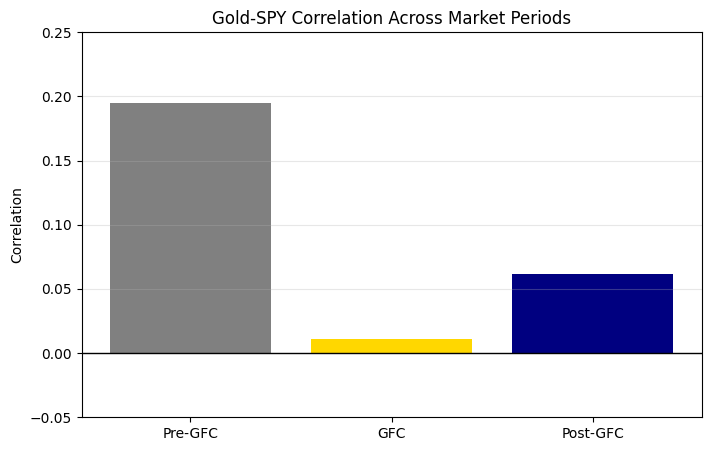

In [54]:
# plot the regime correlations
plt.figure(figsize=(8,5))

plt.bar(
    gfc_comparison["Period"],
    gfc_comparison["Correlation"],
    color= ["gray", "gold", "navy"]
)

plt.axhline(0, color="black", linewidth=1)

plt.title("Gold-SPY Correlation Across Market Periods")
plt.ylabel("Correlation")

plt.ylim(-0.05, 0.25)

plt.grid(axis="y", alpha=0.3)

plt.show()

One of the more interesting patterns is how differently gold behaved across each market regime.

Before the crisis, gold and equities moved more closely together than might be expected. During the GFC, that relationship weakened, which is consistent with gold behaving more independently during a period of severe market stress.

After the crisis, the correlation remained lower than in the pre-GFC period. This does not prove that gold became a permanently stronger diversifier, but it does suggest that its relationship with equities changed after the crisis.

## Output 6- Did Gold Provide More Protection During Sharper Selloffs?

Not all negative market days carry the same level of financial stress. Small daily declines may not reveal much about how diversification behaves during periods of genuine market panic.

To explore this further, the next section isolates trading days where SPY fell by more than 1% and more than 2% to examine whether gold behaved differently during more severe equity market declines.

In [55]:
# focus on larger SPY selloffs to test stress-period behaviour to see whether gold helps more when stress is bigger
spy_down_1 = returns[returns["SPY"] < -0.01]
spy_down_2 = returns[returns["SPY"] < -0.02]

In [56]:
# compare average returns when SPY falls by more than 1% or 2%
selloff_results = pd.DataFrame({
    "SPY down more than 1%": spy_down_1.mean() * 100,
    "SPY down more than 2%": spy_down_2.mean() * 100
})

selloff_results

,SPY down more than 1%,SPY down more than 2%
Gold,-0.068721,-0.046288
SPY,-1.970314,-3.199990


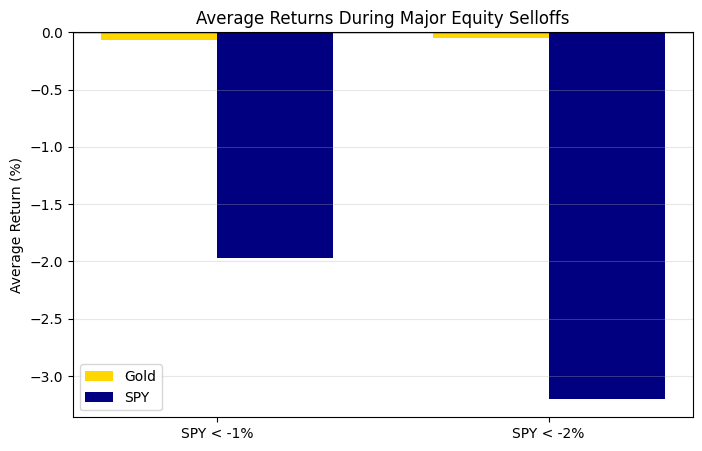

In [57]:
# plot average returns during sharper selloffs
plt.figure(figsize=(8,5))

conditions = ["SPY < -1%", "SPY < -2%"]

gold_values = [
    selloff_results.loc["Gold", "SPY down more than 1%"],
    selloff_results.loc["Gold", "SPY down more than 2%"]
]

spy_values = [
    selloff_results.loc["SPY", "SPY down more than 1%"],
    selloff_results.loc["SPY", "SPY down more than 2%"]
]

x = np.arange(len(conditions))
width = 0.35

plt.bar(x - width/2, gold_values, width, label="Gold", color="gold")
plt.bar(x + width/2, spy_values, width, label="SPY", color="navy")

plt.axhline(0, color="black", linewidth=1)

plt.xticks(x, conditions)

plt.title("Average Returns During Major Equity Selloffs")
plt.ylabel("Average Return (%)")

plt.legend()

plt.grid(axis="y", alpha=0.3)

plt.show()

The results become more interesting once larger equity market declines are isolated.

During sharper SPY selloffs, gold generally held up much better than equities, with the difference becoming more noticeable once SPY fell by more than 1% or 2%.

This supports the idea that gold’s diversification benefits became more useful during more stressful market periods than during normal market conditions.

At the same time, gold was still not a perfect crisis hedge, as there were periods where both assets declined together, even if gold usually fell by far less than equities in this sample.


## Conclusion

At first glance, gold and equities appeared fairly independent across the full sample. But once periods of market stress were isolated, the relationship became more interesting.

The analysis showed that gold often behaved differently from equities during major market declines, particularly during the Global Financial Crisis and more severe SPY selloffs. The rolling correlation analysis also showed that the relationship was not stable over time.

At the same time, the results also showed that gold was not a perfect hedge against equity markets. There were still periods where both assets moved together, especially during broader market-wide declines. This means that gold’s diversification benefits were inconsistent and depended heavily on the surrounding market environment.

Overall, the results suggest that gold functioned less like a constant hedge and more like an asset whose diversification benefits became more noticeable during periods of financial stress. While it did not consistently move opposite to equities, it often helped soften the impact of sharper market declines, particularly during more volatile periods where protecting against downside risk became more important than simply maximising long-run returns.


